# Drug Activity Prediction Using Machine Learning

## Project Overview

The goal of this project is to predict whether a molecule is biologically active against the BACE-1 target using its molecular structure.

The BACE dataset contains molecular structures represented as SMILES strings along with experimentally measured activity labels.

In this project, I will:

- Explore and clean the molecular dataset
- Convert molecular structures into machine-learning features
- Use Morgan fingerprints and molecular descriptors
- Split molecules using a scaffold-based split
- Train and compare different classification models
- Evaluate the models using ROC-AUC and other classification metrics
- Interpret the predictions using feature importance and SHAP
- Build a simple function to predict the activity of a new molecule

The main idea is to investigate whether chemical structure contains enough information to predict biological activity.

## 1. Setup

First, I will install and import the libraries required for data analysis, cheminformatics, machine learning, visualization, and model interpretation.

In [ ]:
!pip install -q rdkit xgboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 30.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, rdFingerprintGenerator, rdMolDescriptors, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import shap

## 2. Loading the BACE Dataset

I will use the BACE dataset from the MoleculeNet benchmark.

The dataset contains molecules represented using SMILES strings and their experimentally determined activity against the BACE-1 target.

Source:

- MoleculeNet / DeepChem
- BACE dataset: https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/bace.csv

I will load the dataset directly into Colab using pandas.

In [ ]:
df = pd.read_csv("https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/bace.csv")
df.shape

(1513, 595)

In [ ]:
df.head()

,mol,CID,Class,Model,pIC50,MW,AlogP,HBA,HBD,RB,...,PEOE6 (PEOE6),PEOE7 (PEOE7),PEOE8 (PEOE8),PEOE9 (PEOE9),PEOE10 (PEOE10),PEOE11 (PEOE11),PEOE12 (PEOE12),PEOE13 (PEOE13),PEOE14 (PEOE14),canvasUID
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,BACE_1,1,Train,9.154901,431.56979,4.4014,3,2,5,...,53.205711,78.640335,226.85541,107.43491,37.133846,0.000000,7.980170,0.0,0.000000,1
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,BACE_2,1,Train,8.853872,657.81073,2.6412,5,4,16,...,73.817162,47.171600,365.67694,174.07675,34.923889,7.980170,24.148668,0.0,24.663788,2
2,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,BACE_3,1,Train,8.698970,591.74091,2.5499,4,3,11,...,70.365707,47.941147,192.40652,255.75255,23.654478,0.230159,15.879790,0.0,24.663788,3
3,S1(=O)(=O)C[C@@H](Cc2cc(O[C@H](COCC)C(F)(F)F)c...,BACE_4,1,Train,8.698970,591.67828,3.1680,4,3,12,...,56.657166,37.954151,194.35304,202.76335,36.498634,0.980913,8.188327,0.0,26.385181,4
4,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,BACE_5,1,Train,8.698970,629.71283,3.5086,3,3,11,...,78.945702,39.361153,179.71288,220.46130,23.654478,0.230159,15.879790,0.0,26.100143,5


### Initial Dataset Inspection

Before building a model, it is important to understand the structure of the dataset.

I will check:

- The available columns
- Data types
- Number of samples
- Missing values
- Distribution of activity labels

This helps identify potential data-quality issues before feature engineering.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Columns: 595 entries, mol to canvasUID
dtypes: float64(210), int64(382), object(3)
memory usage: 6.9+ MB


In [ ]:
df.isnull().sum() #for missing values

,0
mol,0
CID,0
Class,0
Model,0
pIC50,0
...,...
PEOE11 (PEOE11),0
PEOE12 (PEOE12),0
PEOE13 (PEOE13),0
PEOE14 (PEOE14),0


In [ ]:
df["Class"].value_counts()

,count
Class,
0,822
1,691


In [ ]:
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.543291
1,0.456709


This tells us ~54.33% molecules are active , while 45.67% molecules are inactive.
Activity means this molecule was experimentally determined to have sufficient activity/binding against BACE-1.

### Activity Distribution

The target variable is the binary `class` column.

A value of 1 represents an active molecule, while 0 represents an inactive molecule.

Checking the class distribution is important because a heavily imbalanced dataset can make accuracy misleading. For example, a model could achieve high accuracy simply by predicting the majority class for most molecules.

For this reason, I will later use ROC-AUC and PR-AUC in addition to accuracy.

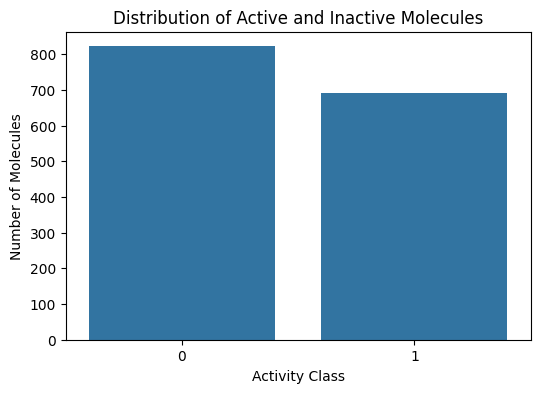

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Active and Inactive Molecules")
plt.xlabel("Activity Class")
plt.ylabel("Number of Molecules")

plt.show()

## 3. Inspecting Molecular Structures

The molecules in the dataset are represented as SMILES strings.

SMILES (Simplified Molecular Input Line Entry System) is a text representation of a molecular structure.

Machine-learning models cannot directly work with these chemical structures, so later I will convert the SMILES strings into numerical representations such as Morgan fingerprints.

First, I will check whether the SMILES strings can be successfully interpreted by RDKit.

In [ ]:
df[["mol", "Class"]].head(10)

,mol,Class
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,1
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,1
2,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,1
3,S1(=O)(=O)C[C@@H](Cc2cc(O[C@H](COCC)C(F)(F)F)c...,1
4,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,1
5,S1(=O)C[C@@H](Cc2cc(OC(C(F)(F)F)C(F)(F)F)c(N)c...,1
6,S(=O)(=O)(CCCCC)C[C@@H](NC(=O)c1cccnc1)C(=O)N[...,1
7,Fc1c2c(ccc1)[C@@]([NH+]=C2N)(C=1C=C(C)C(=O)N(C...,1
8,O1c2c(cc(cc2)CC)[C@@H]([NH2+]C[C@@H](O)[C@H]2N...,1
9,O=C1N(CCCC1)C(C)(C)[C@@H]1C[C@@H](CCC1)C(=O)N[...,1


In [ ]:
# Converting the SMILES strings into RDKit molecule objects
df["molecule"] = df["mol"].apply(Chem.MolFromSmiles)
df["molecule"].head()

,molecule
0,<rdkit.Chem.rdchem.Mol object at 0x7dd7bee647b0>
1,<rdkit.Chem.rdchem.Mol object at 0x7dd7bee64900>
2,<rdkit.Chem.rdchem.Mol object at 0x7dd7bee64970>
3,<rdkit.Chem.rdchem.Mol object at 0x7dd7bee649e0>
4,<rdkit.Chem.rdchem.Mol object at 0x7dd7bee64ac0>


### Checking for Invalid Molecules

RDKit returns `None` when a SMILES string cannot be parsed.

I will therefore check whether any molecules failed during conversion.

In [ ]:
invalid_molecules = df["molecule"].isnull().sum()

print("Invalid molecules:", invalid_molecules)

Invalid molecules: 0


If there were invalid molecules, they wouldn't have converted into molecular features and would need to be removed before training.

But, the number is zero, so all molecules in the dataset were successfully parsed by RDKit.

## 4. Understanding the Dataset Features

The dataset contains both molecular information and experimental information.

Some columns describe the molecular structure, such as molecular weight, hydrogen-bond donors, hydrogen-bond acceptors, and other molecular descriptors.

Other columns contain information about the experiment or dataset itself.

Before training a model, I need to distinguish between:

1. The target variable that I want to predict
2. Molecular features that can be used as model inputs
3. Metadata that should not be used for prediction
4. Measurements that would cause target leakage

In particular, `pIC50` is an experimentally measured activity-related value. Since the objective is to predict activity, using `pIC50` as an input feature would give the model information that would not be available when making a prediction for a new molecule.

In [ ]:
print("Number of columns:", len(df.columns))

for i, column in enumerate(df.columns):
    print(i, column)

Number of columns: 596
0 mol
1 CID
2 Class
3 Model
4 pIC50
5 MW
6 AlogP
7 HBA
8 HBD
9 RB
10 HeavyAtomCount
11 ChiralCenterCount
12 ChiralCenterCountAllPossible
13 RingCount
14 PSA
15 Estate
16 MR
17 Polar
18 sLi_Key
19 ssBe_Key
20 ssssBem_Key
21 sBH2_Key
22 ssBH_Key
23 sssB_Key
24 ssssBm_Key
25 sCH3_Key
26 dCH2_Key
27 ssCH2_Key
28 tCH_Key
29 dsCH_Key
30 aaCH_Key
31 sssCH_Key
32 ddC_Key
33 tsC_Key
34 dssC_Key
35 aasC_Key
36 aaaC_Key
37 ssssC_Key
38 sNH3_Key
39 sNH2_Key
40 ssNH2_Key
41 dNH_Key
42 ssNH_Key
43 aaNH_Key
44 tN_Key
45 sssNH_Key
46 dsN_Key
47 aaN_Key
48 sssN_Key
49 ddsN_Key
50 aasN_Key
51 ssssN_Key
52 daaN_Key
53 sOH_Key
54 dO_Key
55 ssO_Key
56 aaO_Key
57 aOm_Key
58 sOm_Key
59 sF_Key
60 sSiH3_Key
61 ssSiH2_Key
62 sssSiH_Key
63 ssssSi_Key
64 sPH2_Key
65 ssPH_Key
66 sssP_Key
67 dsssP_Key
68 ddsP_Key
69 sssssP_Key
70 sSH_Key
71 dS_Key
72 ssS_Key
73 aaS_Key
74 dssS_Key
75 ddssS_Key
76 ssssssS_Key
77 Sm_Key
78 sCl_Key
79 sGeH3_Key
80 ssGeH2_Key
81 sssGeH_Key
82 ssssGe_Key
83 sAsH2_

### Target and Metadata

For this project, the main prediction target is the `Class` column.

I will not use columns such as `CID`, `Model`, or `canvasUID` as molecular features because they identify compounds or describe how the dataset is organized rather than describing chemical properties.

I will also exclude `pIC50` from the input features because it is an experimentally measured activity-related quantity and would introduce target leakage.

The molecular structure itself will be represented independently using SMILES-derived features.

In [ ]:
# Now, looking at the numerical molecular descriptors
df[["MW", "AlogP", "HBA", "HBD", "RB"]].describe()

,MW,AlogP,HBA,HBD,RB
count,1513.000000,1513.000000,1513.000000,1513.000000,1513.000000
mean,479.661988,3.177080,3.732981,2.001322,8.049570
std,122.083053,1.396633,1.444778,1.629343,4.741135
min,138.187000,-4.361100,0.000000,0.000000,0.000000
25%,389.331300,2.335500,3.000000,0.000000,4.000000
50%,463.628300,3.171300,4.000000,2.000000,7.000000
75%,564.639530,4.015500,4.000000,3.000000,11.000000
max,1350.473300,7.617400,12.000000,15.000000,40.000000


### Basic Molecular Properties

Some of the simplest molecular descriptors are:

- **MW:** molecular weight
- **AlogP:** estimated lipophilicity
- **HBA:** number of hydrogen-bond acceptors
- **HBD:** number of hydrogen-bond donors
- **RB:** number of rotatable bonds

These descriptors provide a compact numerical description of some important molecular properties.

However, they do not capture the complete structural information of a molecule. Therefore, I will later compare descriptor-based features with Morgan fingerprints, which represent molecular substructures.

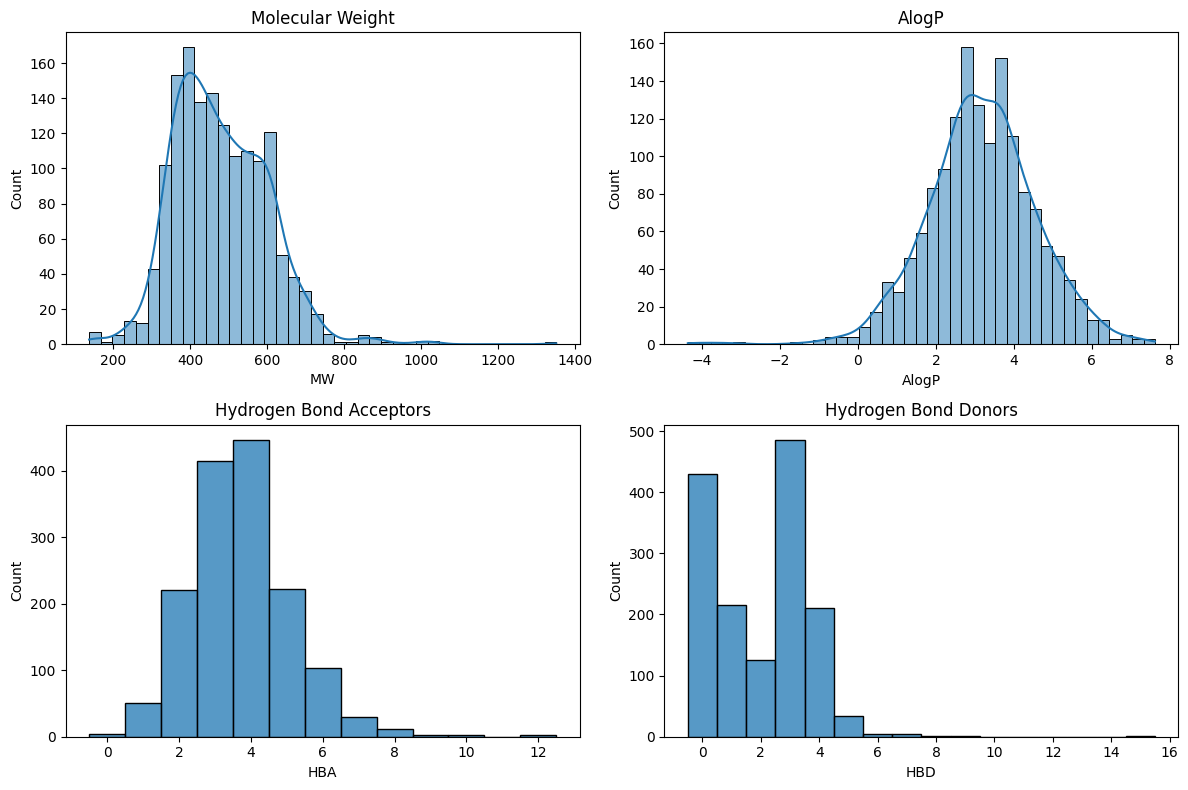

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["MW"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Molecular Weight")

sns.histplot(df["AlogP"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("AlogP")

sns.histplot(df["HBA"], discrete=True, ax=axes[1, 0])
axes[1, 0].set_title("Hydrogen Bond Acceptors")

sns.histplot(df["HBD"], discrete=True, ax=axes[1, 1])
axes[1, 1].set_title("Hydrogen Bond Donors")

plt.tight_layout()
plt.show()

## 5. Molecular Feature Engineering

Machine-learning models require numerical inputs, but our molecules are currently represented as SMILES strings.

I will convert the molecular structures into two different types of numerical features:

1. **Molecular descriptors** — numerical properties such as molecular weight, lipophilicity, hydrogen-bond donors, etc.
2. **Morgan fingerprints** — a representation of the structural subpatterns present in a molecule.

Using both representations allows us to compare whether simple molecular properties or more detailed structural information is more useful for predicting BACE-1 activity.

### Morgan Fingerprints

A Morgan fingerprint represents a molecule using a fixed-length binary vector.

The fingerprint is generated by looking at the local chemical environment around atoms and encoding the molecular substructures that are present.

For example, different parts of a molecule can correspond to features such as:

- Aromatic rings
- Carbonyl groups
- Amine groups
- Particular bond patterns
- Other local chemical environments

Each position in the fingerprint indicates whether a particular structural pattern is present.

I will use a fingerprint size of 2048 bits with a radius of 2.
Why did I choose radius = 2 ? It's rough estimation , the fingerprint considers the chemical environment around each atom up to two bonds away.
This is a common starting point for molecular classification tasks.

In [ ]:
# Creating a Morgan fingerprint generator
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

# Generating a fingerprint for the first molecule
mol = df["molecule"].iloc[0]

fingerprint = morgan_generator.GetFingerprint(mol)

print("Fingerprint length:", len(fingerprint))
print("Number of active bits:", fingerprint.GetNumOnBits())

Fingerprint length: 2048
Number of active bits: 63


In [ ]:
fp_array = np.array(fingerprint)
print(fp_array)

[0 1 0 ... 0 0 0]


### Understanding the Fingerprint

The fingerprint contains 2048 binary values.

A value of:

- `0` means that the corresponding structural feature is not represented in the molecule.
- `1` means that the corresponding structural feature is present.

The fingerprint therefore converts the chemical structure into a numerical representation that machine-learning algorithms can use.

The individual bit positions do not directly correspond to simple descriptors such as molecular weight. Instead, they encode structural environments generated from the molecular graph.

### Generating Features for the Complete Dataset

I will now generate a 2048-bit Morgan fingerprint for every molecule in the BACE dataset.

This will give us a feature matrix where:

- Each row represents one molecule.
- Each column represents one fingerprint bit.
- Each value is either 0 or 1.

In [ ]:
def get_morgan_fingerprint(mol):
    fingerprint = morgan_generator.GetFingerprint(mol)
    return np.array(fingerprint)

fingerprints = np.array([
    get_morgan_fingerprint(mol)
    for mol in df["molecule"]
])

print("Fingerprint matrix shape:", fingerprints.shape)

Fingerprint matrix shape: (1513, 2048)


In [ ]:
print("Number of molecules:", fingerprints.shape[0])
print("Number of fingerprint features:", fingerprints.shape[1])
print("Unique values:", np.unique(fingerprints))

Number of molecules: 1513
Number of fingerprint features: 2048
Unique values: [0 1]


### Interpreting the Feature Matrix

The resulting matrix has 1,513 rows and 2,048 columns.

This means that each molecule is now represented by 2,048 structural features.

The dataset can now be expressed mathematically as:

X ∈ R^(1513 × 2048)

where X contains the molecular fingerprints.

The corresponding target vector is the `Class` column, which contains the experimentally determined active/inactive labels.

In [ ]:
y = df["Class"].values

print("Target shape:", y.shape)
print("Classes:", np.unique(y))

Target shape: (1513,)
Classes: [0 1]


## 6. Avoiding Data Leakage

Before splitting the dataset, I need to make sure that the model only receives information that would realistically be available when predicting the activity of a new molecule.

The target is `Class`.

I will therefore avoid using:

- `Class` itself as an input feature
- `pIC50`, because it is an experimentally measured activity-related quantity
- `CID`, `Model`, and `canvasUID`, because these are identifiers or dataset metadata

The molecular fingerprints are generated directly from the molecular structures and can therefore be used as model inputs.

## 7. Scaffold-Based Data Splitting

A random train-test split is commonly used in machine learning, but it can be problematic for molecular datasets.

Two molecules can have very similar chemical structures while having different activity labels.

If structurally similar molecules are randomly placed into both the training and test sets, the model may effectively see very similar molecules during training and testing.

This can result in an overly optimistic estimate of model performance.

To make the evaluation more realistic, I will use a **scaffold split**.

A molecular scaffold represents the core structural framework of a molecule.

The goal is to ensure that molecules with the same scaffold are kept together rather than being randomly distributed between training and test sets.

This tests whether the model can generalize to molecules with different chemical frameworks.

In [ ]:
def get_scaffold(mol):
    return MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol,
        includeChirality=False
    )

df["scaffold"] = df["molecule"].apply(get_scaffold)

print(df[["mol", "scaffold", "Class"]].head())

                                                 mol  \
0  O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...   
1  Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...   
2  S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...   
3  S1(=O)(=O)C[C@@H](Cc2cc(O[C@H](COCC)C(F)(F)F)c...   
4  S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...   

                                            scaffold  Class  
0          O=C(CCc1cnc2ccc(-c3ccccc3)cc2c1)NC1CCOCC1      1  
1  O=C(NC(Cc1ccccc1)CC1CCC[NH2+]1)C(CCc1ccccc1)N1...      1  
2  O=C(NC(CC[NH2+]Cc1ccccc1)Cc1ccccc1)c1cc2c3c(cc...      1  
3         O=S1(=O)CC(Cc2ccccc2)CC([NH2+]Cc2ccccc2)C1      1  
4  O=C(NC(CC[NH2+]Cc1ccccc1)Cc1ccccc1)c1cc2c3c(cc...      1  


### Inspecting Molecular Scaffolds

The scaffold is the core structural framework extracted from each molecule.

Different molecules can share the same scaffold while having different substituents attached to that core.

I will use these scaffolds to construct the train, validation, and test sets.

In [ ]:
print("Total unique scaffolds:", df["scaffold"].nunique())
print("Total molecules:", len(df))

Total unique scaffolds: 671
Total molecules: 1513


### Creating the Train, Validation, and Test Sets

I will divide the unique molecular scaffolds into three groups:

- **Training set:** 70%
- **Validation set:** 15%
- **Test set:** 15%

All molecules belonging to the same scaffold will remain in the same split.

The validation set will be used for model selection and tuning, while the test set will be kept separate until the final evaluation.

In [ ]:
# Shuffling the unique scaffolds
scaffolds = df["scaffold"].unique()

rng = np.random.default_rng(42)
rng.shuffle(scaffolds)

# Split the scaffolds
n_scaffolds = len(scaffolds)

train_end = int(0.70 * n_scaffolds)
val_end = int(0.85 * n_scaffolds)

train_scaffolds = set(scaffolds[:train_end])
val_scaffolds = set(scaffolds[train_end:val_end])
test_scaffolds = set(scaffolds[val_end:])

print("Training scaffolds:", len(train_scaffolds))
print("Validation scaffolds:", len(val_scaffolds))
print("Test scaffolds:", len(test_scaffolds))

Training scaffolds: 469
Validation scaffolds: 101
Test scaffolds: 101


In [ ]:
train_mask = df["scaffold"].isin(train_scaffolds)
val_mask = df["scaffold"].isin(val_scaffolds)
test_mask = df["scaffold"].isin(test_scaffolds)

X_train = fingerprints[train_mask]
X_val = fingerprints[val_mask]
X_test = fingerprints[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (1081, 2048)
Validation set: (238, 2048)
Test set: (194, 2048)


In [ ]:
train_scaffold_check = set(df.loc[train_mask, "scaffold"])
val_scaffold_check = set(df.loc[val_mask, "scaffold"])
test_scaffold_check = set(df.loc[test_mask, "scaffold"])

print("Train ∩ Validation:", len(train_scaffold_check & val_scaffold_check))
print("Train ∩ Test:", len(train_scaffold_check & test_scaffold_check))
print("Validation ∩ Test:", len(val_scaffold_check & test_scaffold_check))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


### Scaffold Split Verification

The intersections between the three scaffold sets are zero.
i.e.

Train ∩ Validation: 0

Train ∩ Test: 0

Validation ∩ Test: 0

This confirms that no molecular scaffold appears in more than one of the training, validation, and test sets.

This gives a more challenging and chemically meaningful evaluation of whether the model can generalize to structurally different molecules.


| Split | Scaffolds | Molecules | % of molecules |
|---|---:|---:|---:|
| Training | 469 | 1,081 | 71.4% |
| Validation | 101 | 238 | 15.7% |
| Test | 101 | 194 | 12.8% |
| **Total** | **671** | **1,513** | **100%** |

We have 671 unique scaffolds for 1,513 molecules.
That means many molecules share the same underlying structural framework. This is exactly why a scaffold split is useful here, whereas a random split could have placed the molecules from the same chemical family on both sides of the evaluation.

### Checking Activity Distribution Across Splits

Although the complete dataset contains a relatively balanced number of active and inactive molecules, I also need to check the class distribution within each split.

A major difference in class proportions between the training, validation, and test sets could affect model evaluation.

Since this is a scaffold-based split, I do not expect the proportions to be exactly identical.

In [ ]:
print("Training set:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nValidation set:")
print(pd.Series(y_val).value_counts(normalize=True))

print("\nTest set:")
print(pd.Series(y_test).value_counts(normalize=True))

Training set:
0    0.548566
1    0.451434
Name: proportion, dtype: float64

Validation set:
0    0.558824
1    0.441176
Name: proportion, dtype: float64

Test set:
1    0.505155
0    0.494845
Name: proportion, dtype: float64


So, the distribution are as follows:-
| Split | Inactive | Active |
|---|---:|---:|
| Train | 54.86% | 45.14% |
| Validation | 55.88% | 44.12% |
| Test | 49.48% | 50.52% |

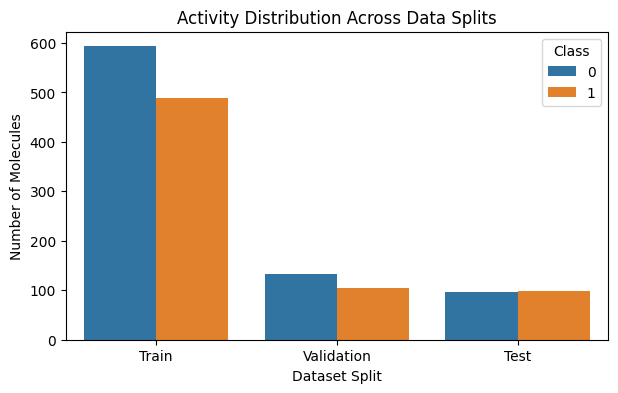

In [ ]:
split_data = pd.DataFrame({
    "Split": (
        ["Train"] * len(y_train) +
        ["Validation"] * len(y_val) +
        ["Test"] * len(y_test)
    ),
    "Class": np.concatenate([y_train, y_val, y_test])
})

plt.figure(figsize=(7, 4))

sns.countplot(
    data=split_data,
    x="Split",
    hue="Class"
)

plt.title("Activity Distribution Across Data Splits")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Molecules")

plt.show()

## 8. Baseline Model — Logistic Regression

I will first train a Logistic Regression classifier using the Morgan fingerprints.

Logistic Regression is a relatively simple classification model and provides a useful baseline for comparison with more complex models.

The model will output a probability that a molecule belongs to the active class.

I will evaluate the model using ROC-AUC rather than relying only on accuracy.

ROC-AUC measures how well the model ranks active molecules above inactive molecules across different classification thresholds.

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Making Predictions

For evaluation, I will use predicted probabilities rather than only the final 0/1 predictions.

The probability of class 1 represents the model's estimated probability that a molecule is active against BACE-1.

In [ ]:
val_prob = logistic_model.predict_proba(X_val)[:, 1]
test_prob = logistic_model.predict_proba(X_test)[:, 1]

print("First 10 validation probabilities: \n", val_prob[:10])

First 10 validation probabilities: 
 [0.96355244 0.84170082 0.94973051 0.93114435 0.97095223 0.57556305
 0.98044577 0.94098778 0.98640968 0.43368931]


In [ ]:
val_auc = roc_auc_score(y_val, val_prob)
test_auc = roc_auc_score(y_test, test_prob)

print(f"Validation ROC-AUC: {val_auc:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")

Validation ROC-AUC: 0.8869
Test ROC-AUC: 0.8545


## 9. Evaluating the Logistic Regression Baseline

ROC-AUC measures the ability of the model to rank active molecules above inactive molecules across different probability thresholds.

However, a practical classifier also requires a decision threshold.

I will initially use 0.5 as the threshold:

- Probability ≥ 0.5 → predicted active
- Probability < 0.5 → predicted inactive

I will then examine accuracy, precision, recall, and the confusion matrix.

In [ ]:
test_pred = (test_prob >= 0.5).astype(int)
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.71      0.81      0.76        96
           1       0.79      0.67      0.73        98

    accuracy                           0.74       194
   macro avg       0.75      0.74      0.74       194
weighted avg       0.75      0.74      0.74       194



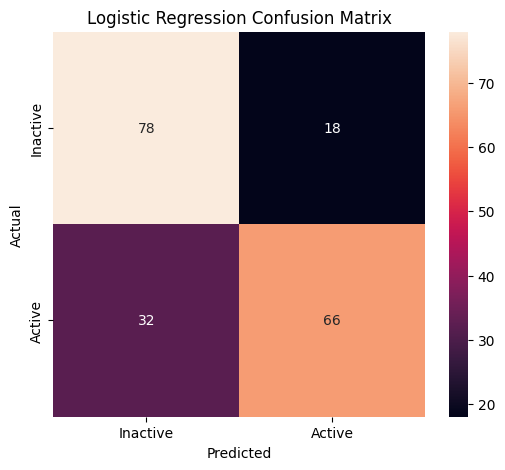

In [ ]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

### ROC Curve

The ROC curve shows the relationship between the true positive rate and false positive rate as the classification threshold changes.

The area under this curve is the ROC-AUC.

A model with an ROC-AUC of 0.5 performs approximately like random ranking, while a value closer to 1.0 indicates better discrimination between active and inactive molecules.

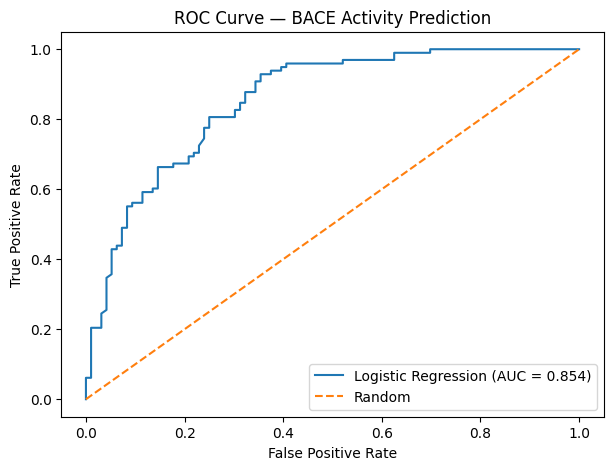

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, test_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — BACE Activity Prediction")
plt.legend()

plt.show()

### Precision-Recall Curve

The precision-recall curve shows the trade-off between precision and recall at different classification thresholds.

I will also calculate the area under this curve (PR-AUC).

PR-AUC is useful because it focuses on the model's ability to identify positive examples while controlling false positives.

In [ ]:
test_pr_auc = average_precision_score(y_test, test_prob)

precision, recall, thresholds = precision_recall_curve(
    y_test,
    test_prob
)

print(f"Test PR-AUC: {test_pr_auc:.4f}")

Test PR-AUC: 0.8366


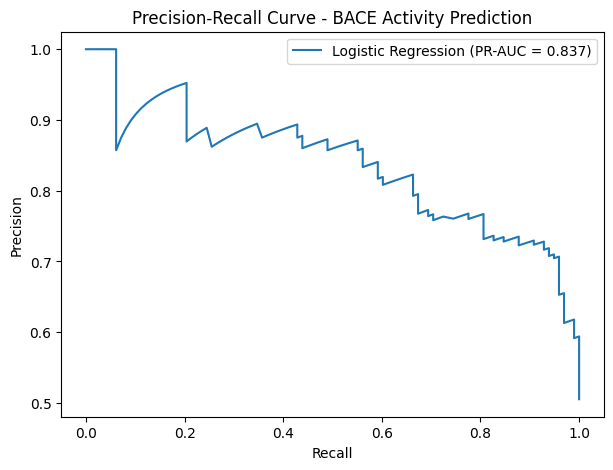

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    label=f"Logistic Regression (PR-AUC = {test_pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - BACE Activity Prediction")
plt.legend()

plt.show()

## 10. Logistic Regression Baseline Results

The Logistic Regression model achieved a test ROC-AUC of approximately 0.85 and a PR-AUC of approximately 0.84 using Morgan fingerprints and a scaffold-based test set.

At a probability threshold of 0.5, the model achieved 74% accuracy.

The model identified 66 out of 98 active molecules in the test set, corresponding to a recall of 0.67 for the active class.

The ROC-AUC is more informative than accuracy for comparing models because it evaluates the model's ranking ability across different classification thresholds.

This Logistic Regression model will serve as the baseline against which more flexible models can be compared.

## 11. Random Forest

The next model is a Random Forest classifier.

A Random Forest combines many decision trees and can capture nonlinear relationships between molecular features and biological activity.

Unlike Logistic Regression, which models a relatively simple relationship between the input features and the prediction, a Random Forest can model interactions between different fingerprint bits.

I will initially use a reasonable set of parameters rather than extensively tuning the model. This gives us a fair baseline comparison before optimization.

In [ ]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
rf_val_prob = random_forest.predict_proba(X_val)[:, 1]
rf_test_prob = random_forest.predict_proba(X_test)[:, 1]

rf_val_auc = roc_auc_score(y_val, rf_val_prob)
rf_test_auc = roc_auc_score(y_test, rf_test_prob)

print(f"Validation ROC-AUC: {rf_val_auc:.4f}")
print(f"Test ROC-AUC: {rf_test_auc:.4f}")

Validation ROC-AUC: 0.8960
Test ROC-AUC: 0.9043


In [ ]:
rf_test_pr_auc = average_precision_score(y_test, rf_test_prob)
print(f"Test PR-AUC: {rf_test_pr_auc:.4f}")

Test PR-AUC: 0.8908


## 12. Comparing the First Two Models

Both models were trained using the same Morgan fingerprint representation and the same scaffold-based train/validation/test split.

This allows the model architecture itself to be compared more fairly.

I will compare their ROC-AUC and PR-AUC on the held-out test set.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "ROC-AUC": [
        test_auc,
        rf_test_auc
    ],
    "PR-AUC": [
        test_pr_auc,
        rf_test_pr_auc
    ]
})

results

,Model,ROC-AUC,PR-AUC
0,Logistic Regression,0.854486,0.836590
1,Random Forest,0.904337,0.890769


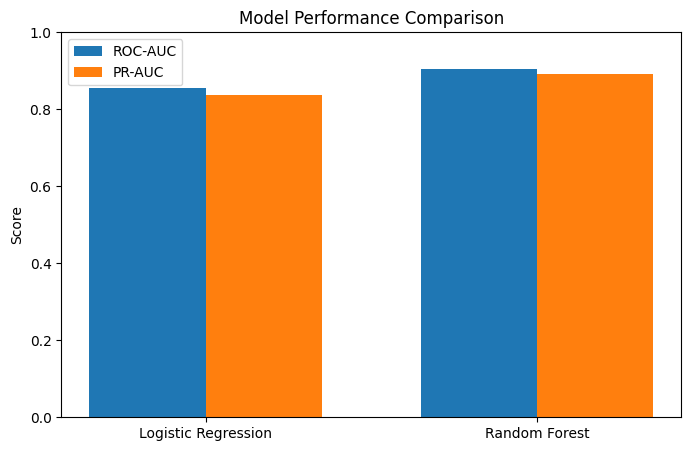

In [ ]:
plt.figure(figsize=(8, 5))

x = np.arange(len(results))
width = 0.35

plt.bar(
    x - width/2,
    results["ROC-AUC"],
    width,
    label="ROC-AUC"
)

plt.bar(
    x + width/2,
    results["PR-AUC"],
    width,
    label="PR-AUC"
)

plt.xticks(x, results["Model"])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()

### Initial Model Comparison

Random Forest performed substantially better than Logistic Regression on the held-out scaffold-based test set.

The Random Forest achieved a test ROC-AUC of approximately 0.90 compared with approximately 0.85 for Logistic Regression.

This suggests that nonlinear relationships and interactions between molecular substructures are useful for predicting BACE-1 activity.

However, this comparison only considers two models. I will next evaluate XGBoost to determine whether a gradient-boosted tree model can improve further on the Random Forest baseline.

## 13. XGBoost

XGBoost is a gradient boosting algorithm that builds a sequence of decision trees.

Each new tree attempts to improve the predictions made by the previous trees.

Compared with Random Forest, which builds many relatively independent trees and combines their predictions, gradient boosting builds trees sequentially to correct previous errors.

I will use XGBoost with a moderate set of parameters as another baseline model.

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_val_prob = xgb_model.predict_proba(X_val)[:, 1]
xgb_test_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_val_auc = roc_auc_score(y_val, xgb_val_prob)
xgb_test_auc = roc_auc_score(y_test, xgb_test_prob)

xgb_test_pr_auc = average_precision_score(
    y_test,
    xgb_test_prob
)

print(f"Validation ROC-AUC: {xgb_val_auc:.4f}")
print(f"Test ROC-AUC: {xgb_test_auc:.4f}")
print(f"Test PR-AUC: {xgb_test_pr_auc:.4f}")

Validation ROC-AUC: 0.8929
Test ROC-AUC: 0.8940
Test PR-AUC: 0.8885


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC": [
        test_auc,
        rf_test_auc,
        xgb_test_auc
    ],
    "PR-AUC": [
        test_pr_auc,
        rf_test_pr_auc,
        xgb_test_pr_auc
    ]
})

results.sort_values("ROC-AUC", ascending=False)

,Model,ROC-AUC,PR-AUC
1,Random Forest,0.904337,0.890769
2,XGBoost,0.894026,0.888514
0,Logistic Regression,0.854486,0.836590


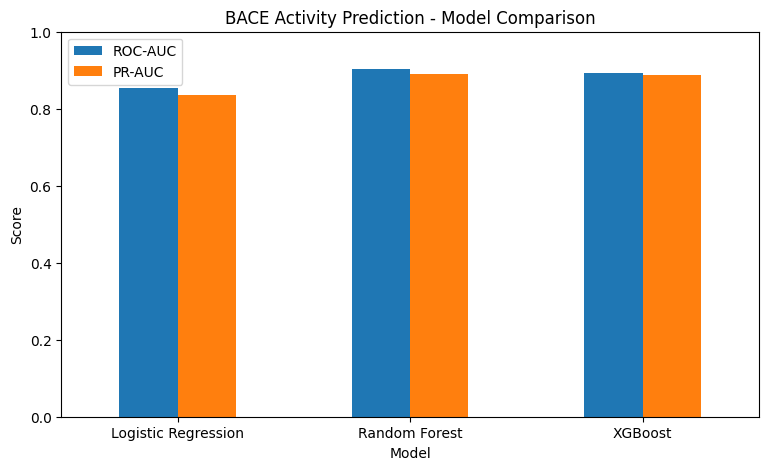

In [ ]:
results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("BACE Activity Prediction - Model Comparison")
plt.xticks(rotation=0)
plt.legend()

plt.show()

### Comparison of Classical Machine Learning Models

The three models produced different levels of performance when evaluated on the same scaffold-based test set.

Random Forest achieved the highest test ROC-AUC of 0.9043 and the highest PR-AUC of 0.8908.

XGBoost performed similarly, with a test ROC-AUC of 0.8940 and PR-AUC of 0.8885.

Logistic Regression had the lowest performance, with a test ROC-AUC of 0.8545.

The improvement from Logistic Regression to the tree-based models suggests that nonlinear relationships between molecular substructures and BACE-1 activity are important.

For the remainder of the project, Random Forest will be treated as the best-performing model from this initial comparison.

## 14. Molecular Descriptor-Based Modeling

Morgan fingerprints capture local structural patterns, but they are not the only way to represent a molecule.

Another approach is to describe each molecule using numerical physicochemical and molecular descriptors.

Examples include:

- Molecular weight
- Lipophilicity
- Hydrogen-bond donors
- Hydrogen-bond acceptors
- Rotatable bonds

The BACE dataset already contains calculated descriptors, but I will construct a clean descriptor set from the molecular structures using RDKit.

This avoids relying on potentially target-related or dataset-specific columns in the original CSV.

I will then train a Random Forest using only these descriptors and compare its performance with the fingerprint-based Random Forest.

In [ ]:
def calculate_descriptors(mol):
    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.TPSA(mol),
        Descriptors.RingCount(mol),
        Descriptors.NumAromaticRings(mol),
        Descriptors.FractionCSP3(mol)
    ]


descriptor_names = [
    "MolecularWeight",
    "LogP",
    "HBD",
    "HBA",
    "RotatableBonds",
    "TPSA",
    "RingCount",
    "AromaticRings",
    "FractionCSP3"
]

descriptor_matrix = np.array([
    calculate_descriptors(mol)
    for mol in df["molecule"]
])

descriptors_df = pd.DataFrame(
    descriptor_matrix,
    columns=descriptor_names
)

descriptors_df.head()

,MolecularWeight,LogP,HBD,HBA,RotatableBonds,TPSA,RingCount,AromaticRings,FractionCSP3
0,431.580,5.04482,2.0,4.0,5.0,77.24,4.0,3.0,0.407407
1,657.823,2.63860,4.0,5.0,16.0,124.58,4.0,2.0,0.583333
2,591.754,2.45750,3.0,5.0,11.0,117.48,5.0,4.0,0.343750
3,591.688,3.13180,3.0,6.0,10.0,115.46,3.0,2.0,0.571429
4,629.725,3.46770,3.0,4.0,10.0,108.25,5.0,4.0,0.343750


In [ ]:
descriptor_matrix.shape

(1513, 9)

In [ ]:
descriptors_df.describe().T

,count,mean,std,min,25%,50%,75%,max
MolecularWeight,1513.0,479.671640,122.085059,138.190,389.3370,463.639000,564.6500,1350.495000
LogP,1513.0,3.124880,1.247588,-6.457,2.4165,3.137700,3.8769,7.293300
HBD,1513.0,2.435558,1.242429,1.000,1.0000,3.000000,3.0000,15.000000
HBA,1513.0,4.699934,1.565537,0.000,4.0000,5.000000,6.0000,18.000000
RotatableBonds,1513.0,7.679445,4.687279,0.000,4.0000,7.000000,11.0000,40.000000
TPSA,1513.0,95.187958,33.187410,16.610,72.9400,90.690000,110.1800,525.060000
RingCount,1513.0,3.777264,0.892331,0.000,3.0000,4.000000,4.0000,7.000000
AromaticRings,1513.0,2.565763,0.830036,0.000,2.0000,3.000000,3.0000,5.000000
FractionCSP3,1513.0,0.369848,0.155931,0.000,0.2500,0.363636,0.5000,0.894737


### Descriptor Interpretation

The descriptor representation contains only nine features, compared with 2,048 Morgan fingerprint features.

These descriptors describe broad molecular properties rather than individual structural subpatterns.

This provides a useful comparison between two different levels of molecular representation:

**Descriptors**
-> compact representation of global molecular properties

**Morgan fingerprints**
-> high-dimensional representation of local structural patterns

In [ ]:
X_desc_train = descriptor_matrix[train_mask]
X_desc_val = descriptor_matrix[val_mask]
X_desc_test = descriptor_matrix[test_mask]

print("Training:", X_desc_train.shape)
print("Validation:", X_desc_val.shape)
print("Test:", X_desc_test.shape)

Training: (1081, 9)
Validation: (238, 9)
Test: (194, 9)


In [ ]:
descriptor_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

descriptor_rf.fit(X_desc_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
desc_test_prob = descriptor_rf.predict_proba(X_desc_test)[:, 1]

desc_test_auc = roc_auc_score(
    y_test,
    desc_test_prob
)

desc_test_pr_auc = average_precision_score(
    y_test,
    desc_test_prob
)

print(f"Descriptor RF ROC-AUC: {desc_test_auc:.4f}")
print(f"Descriptor RF PR-AUC: {desc_test_pr_auc:.4f}")

Descriptor RF ROC-AUC: 0.7949
Descriptor RF PR-AUC: 0.7783


## 15. Molecular Representation Comparison

| Representation | Model | Test ROC-AUC | Test PR-AUC |
|---|---|---:|---:|
| Morgan fingerprints | Logistic Regression | 0.8545 | 0.8366 |
| **Morgan fingerprints** | **Random Forest** | **0.9043** | **0.8908** |
| Morgan fingerprints | XGBoost | 0.8940 | 0.8885 |
| Molecular descriptors | Random Forest | 0.7949 | 0.7783 |


I compared two different representations of the same molecules.

The descriptor-based representation contains nine global molecular properties, while the Morgan fingerprint contains 2,048 structural features.

Using the same Random Forest algorithm and the same scaffold-based train/validation/test split, the descriptor model achieved a test ROC-AUC of 0.7949, whereas the Morgan fingerprint model achieved 0.9043.

This difference suggests that the local structural information captured by Morgan fingerprints provides substantially more useful information for predicting BACE-1 activity than the small set of global physicochemical descriptors used here.

Therefore, molecular representation appears to be an important factor in the performance of the activity prediction model.

In [ ]:
representation_results = pd.DataFrame({
    "Representation": [
        "Morgan Fingerprint",
        "Molecular Descriptors"
    ],
    "ROC-AUC": [
        rf_test_auc,
        desc_test_auc
    ],
    "PR-AUC": [
        rf_test_pr_auc,
        desc_test_pr_auc
    ]
})

representation_results

,Representation,ROC-AUC,PR-AUC
0,Morgan Fingerprint,0.904337,0.890769
1,Molecular Descriptors,0.794909,0.778330


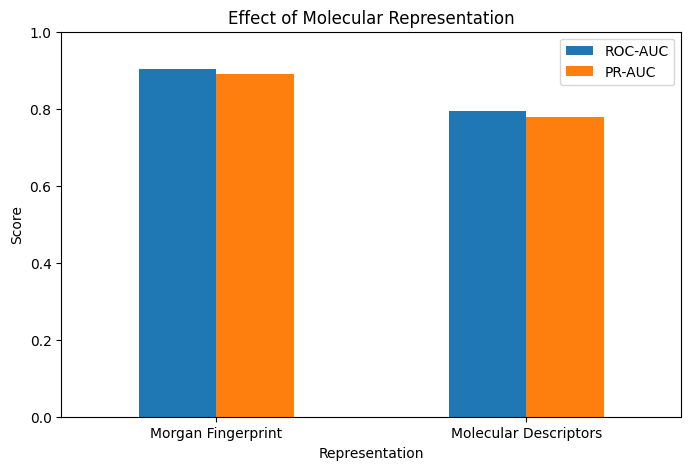

In [ ]:
plot_data = representation_results.set_index("Representation")

plot_data.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Effect of Molecular Representation")
plt.xticks(rotation=0)
plt.legend()

plt.show()

## 16. Interpreting the Random Forest

The Random Forest model achieved the best performance among the models tested so far.

However, predictive performance alone does not tell us which molecular features are contributing to the predictions.

I will therefore examine the feature importance assigned to the Morgan fingerprint bits.

This can help identify which structural patterns are most useful to the model when distinguishing active and inactive molecules.

It is important to note that a fingerprint bit represents a structural pattern rather than a simple chemical property such as molecular weight or LogP.

In [ ]:
feature_importance = random_forest.feature_importances_

print("Number of fingerprint features:", len(feature_importance))
print("Total importance:", feature_importance.sum())

Number of fingerprint features: 2048
Total importance: 1.0


In [ ]:
importance_df = pd.DataFrame({
    "Bit": np.arange(2048),
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Bit,Importance
1840,1840,0.009994
464,464,0.007492
1928,1928,0.007340
664,664,0.006900
1452,1452,0.006595
1902,1902,0.006527
1453,1453,0.006293
126,126,0.005481
1563,1563,0.005373
1050,1050,0.005339


### Most Important Fingerprint Features

The table above shows the fingerprint bits that received the highest feature importance from the Random Forest.

A higher importance means that the corresponding feature contributed more to the model's decision-making across the trees.

However, the bit number itself does not have an intuitive chemical interpretation.

Therefore, I will next map important fingerprint bits back to the molecular substructures that generated them.

In [ ]:
# Generating a fingerprint with information about which atoms contributed to each fingerprint bit

bit_info = {}

example_mol = df["molecule"].iloc[0]

example_fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(
    example_mol,
    radius=2,
    nBits=2048,
    bitInfo=bit_info
)

print("Number of active bits:", example_fp.GetNumOnBits())
print("Number of bits with atom information:", len(bit_info))

Number of active bits: 63
Number of bits with atom information: 63


[04:49:07] DEPRECATION WARNING: please use MorganGenerator


In [ ]:
important_bit = importance_df.iloc[0]["Bit"]
print("Most important fingerprint bit:", important_bit)

Most important fingerprint bit: 1840.0


In [ ]:
# Finding the molecules where this fingerprint bit is present
bit_present = []

for i, mol in enumerate(df["molecule"]):
    fp = morgan_generator.GetFingerprint(mol)

    if fp.GetBit(int(important_bit)) == 1:
        bit_present.append(i)

print("Number of molecules containing this bit:", len(bit_present))

Number of molecules containing this bit: 195


### Interpreting an Important Structural Feature

The fingerprint bit identified by the Random Forest corresponds to a particular local molecular environment.

The presence of this bit does not necessarily mean that the structural feature directly causes biological activity.

Instead, it means that this structural pattern was useful for distinguishing active and inactive molecules within this dataset.

To avoid over-interpreting individual fingerprint bits, I will examine several important features and use them as model interpretation rather than claiming direct biological causation.

## 17. SHAP Model Interpretation

SHAP (SHapley Additive exPlanations) provides a way to estimate how individual features contribute to a model's prediction.

For this project, SHAP values can help answer:

> Which molecular fingerprint features are pushing a prediction toward active or inactive?

Positive SHAP values indicate that a feature is contributing toward the active prediction, while negative values contribute toward the inactive prediction.

Because calculating SHAP values for thousands of molecules and thousands of fingerprint features can be computationally expensive, I will use a representative subset of the test set.

In [ ]:
# Using a small subset of the test set for SHAP
sample_size = min(100, len(X_test))

X_shap = X_test[:sample_size]

X_shap.shape

(100, 2048)

In [ ]:
explainer = shap.TreeExplainer(random_forest)

shap_values = explainer.shap_values(X_shap)

In [ ]:
#Checking the SHAP output format
print(type(shap_values))

if isinstance(shap_values, list):
    print("Number of SHAP outputs:", len(shap_values))
    print("Shape of class 1 SHAP values:", shap_values[1].shape)
else:
    print("SHAP values shape:", shap_values.shape)

<class 'numpy.ndarray'>
SHAP values shape: (100, 2048, 2)


In [ ]:
# Geting SHAP values for the active class

if isinstance(shap_values, list):
    shap_active = shap_values[1]
else:
    # Newer SHAP versions may return an array with
    # the class dimension at the end
    if shap_values.ndim == 3:
        shap_active = shap_values[:, :, 1]
    else:
        shap_active = shap_values

shap_active.shape

(100, 2048)

### Global SHAP Importance

For each molecule, SHAP assigns a contribution to each fingerprint feature.

I will calculate the average absolute SHAP value of each feature across the sampled molecules.

A larger value means that the feature generally has a larger influence on the model's predictions.

This provides a global view of which fingerprint features are most influential.

In [ ]:
mean_shap = np.abs(shap_active).mean(axis=0)

shap_importance = pd.DataFrame({
    "Bit": np.arange(2048),
    "Mean_Absolute_SHAP": mean_shap
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

shap_importance.head(20)

,Bit,Mean_Absolute_SHAP
1902,1902,0.015646
1840,1840,0.013647
1928,1928,0.011800
1563,1563,0.011368
1452,1452,0.009902
938,938,0.008659
664,664,0.008340
699,699,0.008185
932,932,0.007454
1742,1742,0.007166


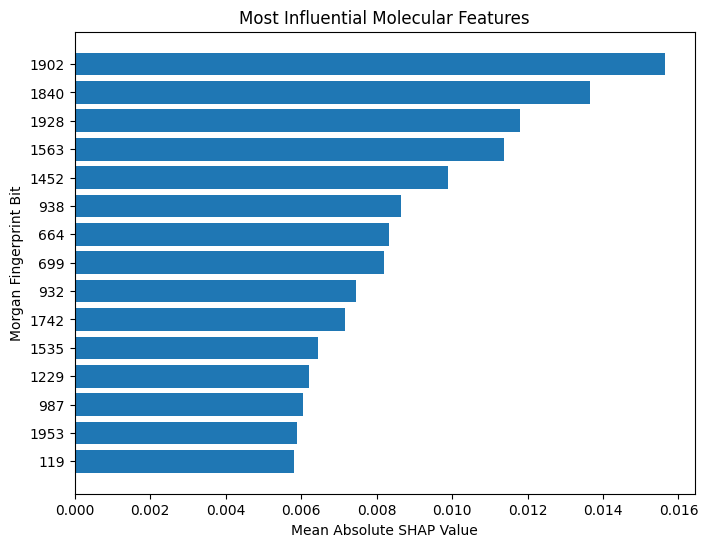

In [ ]:
top_shap = shap_importance.head(15).sort_values(
    "Mean_Absolute_SHAP"
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_shap["Bit"].astype(str),
    top_shap["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Morgan Fingerprint Bit")
plt.title("Most Influential Molecular Features")

plt.show()

### Interpreting the SHAP Results

The SHAP analysis identifies fingerprint features that have a large influence on the model's predictions.

These features should be interpreted as model-level associations rather than direct evidence that a particular chemical substructure causes BACE-1 activity.

The model has learned statistical relationships between molecular structure and activity from the training data.

The next step is to connect these fingerprint bits back to actual molecular substructures where possible.

## 18. Connecting Fingerprint Features to Molecular Structure

Morgan fingerprint bits are numerical identifiers, so a bit number alone is not chemically meaningful.

RDKit allows us to trace a fingerprint bit back to the atom and local environment that generated it.

I will use one of the important fingerprint features identified above and visualize its corresponding molecular environment.

In [ ]:
important_bit = int(shap_importance.iloc[0]["Bit"])
print("Selected fingerprint bit:", important_bit)

Selected fingerprint bit: 1902


In [ ]:
#Finding the first molecule containing this fingerprint bit
example_index = None

for i, mol in enumerate(df["molecule"]):
    fp = morgan_generator.GetFingerprint(mol)

    if fp.GetBit(important_bit):
        example_index = i
        break

print("Example molecule index:", example_index)
print("SMILES:", df["mol"].iloc[example_index])
print("Activity class:", df["Class"].iloc[example_index])

Example molecule index: 41
SMILES: Fc1ccc(cc1C#CCCCF)[C@]1(N=C(N)N(C)C1=O)c1ccc(OC(F)F)cc1
Activity class: 1


In [ ]:
#Generating bit information for this molecule
bit_info = {}

mol = df["molecule"].iloc[example_index]

fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(
    mol,
    radius=2,
    nBits=2048,
    bitInfo=bit_info
)

print("Selected bit information:")
print(bit_info.get(important_bit))

Selected bit information:
((4, 2),)


[04:51:21] DEPRECATION WARNING: please use MorganGenerator


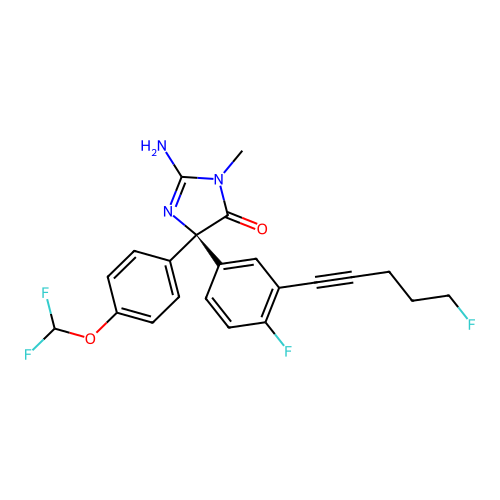

In [ ]:
Draw.MolToImage(mol, size=(500, 500))

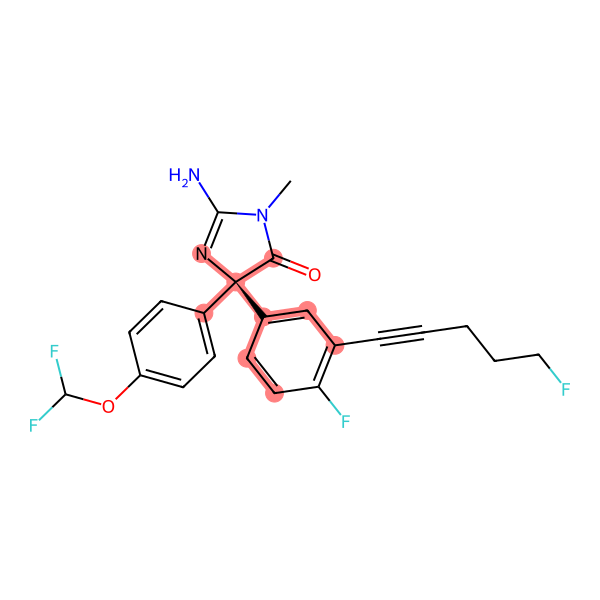

In [ ]:
from rdkit.Chem.Draw import rdMolDraw2D

bit_atoms = []
bit_bonds = []

for atom_idx, radius in bit_info.get(important_bit, []):
    env = Chem.FindAtomEnvironmentOfRadiusN(
        mol,
        radius,
        atom_idx
    )

    atoms = set()

    for bond_idx in env:
        bond = mol.GetBondWithIdx(bond_idx)
        atoms.add(bond.GetBeginAtomIdx())
        atoms.add(bond.GetEndAtomIdx())

    bit_atoms.extend(list(atoms))
    bit_bonds.extend(list(env))

bit_atoms = list(set(bit_atoms))
bit_bonds = list(set(bit_bonds))

drawer = rdMolDraw2D.MolDraw2DCairo(600, 600)

drawer.DrawMolecule(
    mol,
    highlightAtoms=bit_atoms,
    highlightBonds=bit_bonds
)

drawer.FinishDrawing()

from IPython.display import display, Image

display(Image(drawer.GetDrawingText()))

### Interpretation Caveat

The highlighted molecular environment should not be interpreted as a proven BACE-1 pharmacophore.

The Random Forest identifies statistical associations in the training data. A fingerprint feature may be correlated with activity because it occurs alongside other structural features or because of the chemical series represented in the dataset.

Therefore, the model interpretation is useful for understanding the model's behavior, but it does not establish a causal relationship between a specific substructure and biological activity.

## 19. Predicting Activity for a New Molecule

The trained Random Forest model can be used to make predictions for molecules that were not part of the training process.

The prediction pipeline is:

SMILES
→ RDKit molecular structure
→ Morgan fingerprint
→ Random Forest
→ Probability of BACE-1 activity

The model outputs a probability between 0 and 1. I will use 0.5 as the initial threshold for converting this probability into an active/inactive prediction.

In [ ]:
def predict_activity(smiles):
    # Convert SMILES into an RDKit molecule
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return "Invalid SMILES"

    # Generate Morgan fingerprint
    fingerprint = morgan_generator.GetFingerprint(mol)
    fingerprint = np.array(fingerprint).reshape(1, -1)

    # Predict probability of being active
    probability = random_forest.predict_proba(fingerprint)[0, 1]

    # Convert probability to a class
    prediction = "Active" if probability >= 0.5 else "Inactive"

    return prediction, probability

In [ ]:
test_index = np.where(test_mask)[0][0]

test_smiles = df["mol"].iloc[test_index]
actual_class = df["Class"].iloc[test_index]

prediction, probability = predict_activity(test_smiles)

print("SMILES:", test_smiles)
print("Actual class:", "Active" if actual_class == 1 else "Inactive")
print("Predicted class:", prediction)
print(f"Predicted probability of activity: {probability:.3f}")

SMILES: Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(=O)C)(CC(C)C)C1=O)CCc1ccccc1)[C@H](O)[C@@H]1[NH2+]C[C@H](OCCC)C1
Actual class: Active
Predicted class: Active
Predicted probability of activity: 0.811


### Predictions on Unseen Test Molecules

I will now apply the prediction function to several molecules from the held-out test set.

These molecules were not used when fitting the Random Forest model.

Comparing the predictions with their actual labels provides an intuitive example of how the trained model behaves on unseen chemical structures.

In [ ]:
sample_indices = np.where(test_mask)[0][:10]

prediction_results = []

for index in sample_indices:
    smiles = df["mol"].iloc[index]
    actual = df["Class"].iloc[index]

    predicted_class, probability = predict_activity(smiles)

    prediction_results.append({
        "SMILES": smiles,
        "Actual": "Active" if actual == 1 else "Inactive",
        "Predicted": predicted_class,
        "Activity Probability": round(probability, 3)
    })

prediction_df = pd.DataFrame(prediction_results)

prediction_df

,SMILES,Actual,Predicted,Activity Probability
0,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,Active,Active,0.811
1,S(=O)(=O)(CCCCC)C[C@@H](NC(=O)c1cccnc1)C(=O)N[...,Active,Active,0.627
2,Fc1cc(cc(F)c1)C[C@H](NC(=O)c1cc(cc(c1)C)C(=O)N...,Active,Inactive,0.495
3,Fc1cc(cc(F)c1)C[C@H](NC(=O)c1cc(cc(c1)C)C(=O)N...,Active,Active,0.538
4,O=C1N(CCC1)c1cc(cc(NCC)c1)C(=O)N[C@H]([C@H](O)...,Active,Inactive,0.270
5,O1c2c(cc(cc2)CC)[C@@H]([NH2+]C[C@@H](O)[C@H]2N...,Active,Active,0.937
6,S1(=O)(=O)N(c2c(CCC1)c(NCC)cc(c2)C(=O)N[C@H]([...,Active,Active,0.793
7,Fc1ccc(cc1-c1cncnc1)[C@]1(N=C(N)N(C)C1=O)c1ccc...,Active,Active,0.593
8,S(=O)(=O)(N(C)c1cc(cc(c1)COC(=O)[C@]([NH3+])(C...,Active,Inactive,0.030
9,O(C)c1ccc(cc1C)[C@@]1(N=C(N)N(C)C1=O)c1cc(ccc1...,Active,Active,0.573


### Prediction Confidence

The Random Forest produces a probability rather than only a binary classification.

A probability close to 0.5 indicates that the model is relatively uncertain, while probabilities closer to 0 or 1 indicate stronger model confidence.

However, these probabilities should not automatically be interpreted as experimentally calibrated probabilities of biological activity.

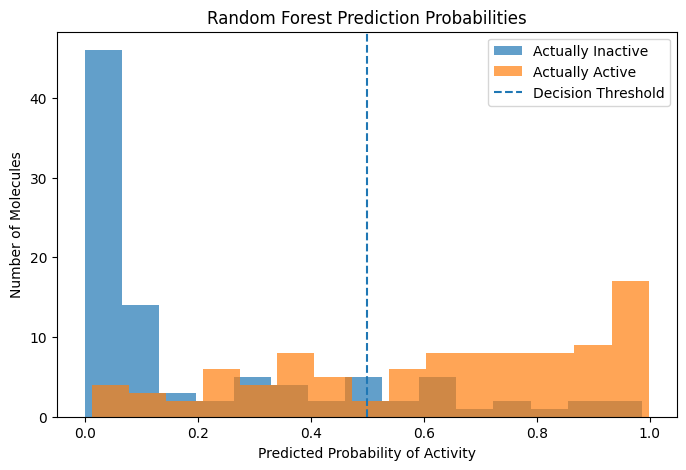

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    test_prob[y_test == 0],
    bins=15,
    alpha=0.7,
    label="Actually Inactive"
)

plt.hist(
    test_prob[y_test == 1],
    bins=15,
    alpha=0.7,
    label="Actually Active"
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Decision Threshold"
)

plt.xlabel("Predicted Probability of Activity")
plt.ylabel("Number of Molecules")
plt.title("Random Forest Prediction Probabilities")
plt.legend()

plt.show()

## 20. Final Model Comparison

The models were evaluated using the same scaffold-based test set.

This ensures that differences in performance primarily reflect differences in the molecular representation and model architecture rather than differences in the test data.

In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Descriptor Random Forest"
    ],
    "Representation": [
        "Morgan Fingerprint",
        "Morgan Fingerprint",
        "Morgan Fingerprint",
        "RDKit Descriptors"
    ],
    "Test ROC-AUC": [
        test_auc,
        rf_test_auc,
        xgb_test_auc,
        desc_test_auc
    ],
    "Test PR-AUC": [
        test_pr_auc,
        rf_test_pr_auc,
        xgb_test_pr_auc,
        desc_test_pr_auc
    ]
})

final_results.sort_values(
    "Test ROC-AUC",
    ascending=False
)

,Model,Representation,Test ROC-AUC,Test PR-AUC
1,Random Forest,Morgan Fingerprint,0.904337,0.890769
2,XGBoost,Morgan Fingerprint,0.894026,0.888514
0,Logistic Regression,Morgan Fingerprint,0.854486,0.836590
3,Descriptor Random Forest,RDKit Descriptors,0.794909,0.778330


## 21. Conclusion

This project investigated whether molecular structure could be used to predict biological activity against the BACE-1 target.

Morgan fingerprints consistently provided better predictive information than the small set of molecular descriptors evaluated in this project.

Among the three models trained on Morgan fingerprints, Random Forest achieved the best performance, with a test ROC-AUC of 0.9043 and PR-AUC of 0.8908 on the scaffold-based test set.

Logistic Regression achieved a lower ROC-AUC of 0.8545, suggesting that nonlinear relationships between structural features and activity are important for this dataset. XGBoost achieved a ROC-AUC of 0.8940, performing similarly to but slightly below Random Forest.

The descriptor-based Random Forest achieved a ROC-AUC of 0.7949, indicating that the structural information captured by Morgan fingerprints provided additional predictive value beyond the selected global molecular descriptors.

Overall, the results demonstrate that machine-learning models can learn useful relationships between molecular structure and BACE-1 activity. However, model predictions represent statistical associations and should not be treated as experimental confirmation of biological activity.

The next step for improving the project would be model optimization, uncertainty analysis, and evaluation on an independent external dataset.